# Set-Up
Package and data importing

In [1]:
# essential package imports
import pandas as pd
from data_analysis import combine_pipeline_csvs_to_lexical_master, clean_and_prepare_lexical_df
from series_analysis import run_stationarity_tests, summarize_stationarity, plot_stationarity_heatmap, run_ljung_box_tests, summarize_ljung_box, plot_ljung_box_heatmap, first_difference
from data_analysis import plot_acf_grid
from visualization import *

In [3]:
# read in data file as pandas dataframe
# raw_text is excluded via usecols to cut down read time
COLS_TO_LOAD = [
    'utterance_id',
    'speaker_id',
    'timestamp',
    'num_utterances_by_speaker',
    'num_utterances_by_speaker_month',
    'post_depth',
    'score',
    'num_direct_replies',
    'mtld_score',
    'mattr_score',
    'yules_k',
    'zipf_score',
    'aoa_score',
    'nawl_ratio',
    'source_variation',
    'subreddit',
]

METRICS = ['mtld_score', 'mattr_score', 'yules_k', 'zipf_score', 'aoa_score', 'nawl_ratio']

df = pd.read_csv(
    '/Users/nickvick/Library/CloudStorage/OneDrive-PrincetonUniversity/ORFE/Thesis/Thesis-Data/lexical_master.csv',
    usecols=COLS_TO_LOAD,
)

df = clean_and_prepare_lexical_df(df)

# Temporal Analysis
Examine the trends of each metric—all positively correlated with lexical quality—over time

## Initial Visualization

/Users/nickvick/Desktop/Thesis/ORFE-Thesis/src/visualization.py:233: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  resampled  = series.resample(resample_freq).agg(['mean', 'std', 'count'])


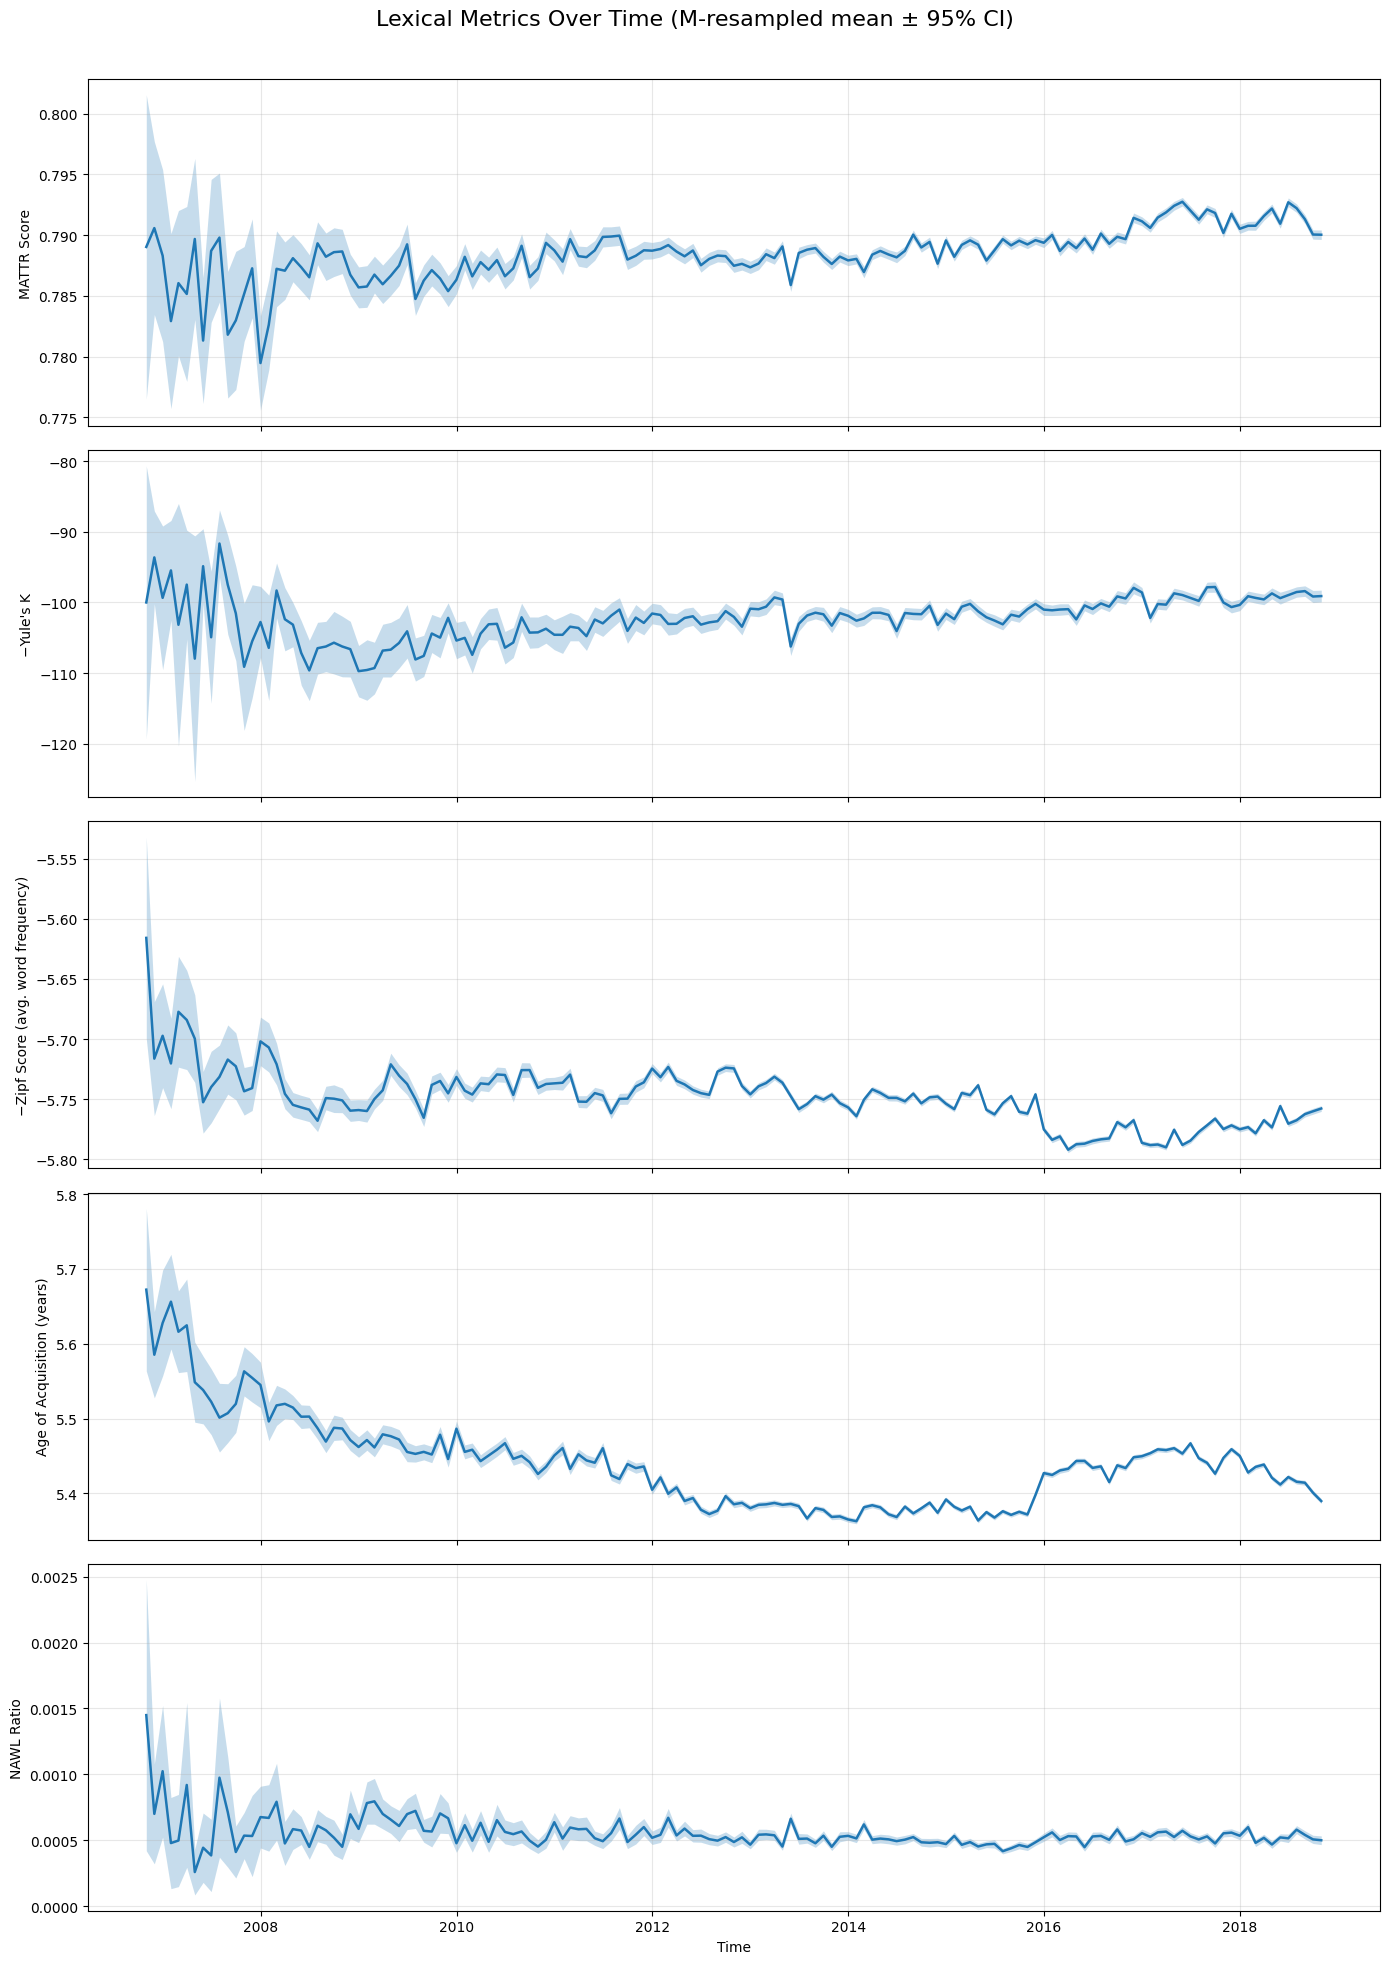

In [ ]:
plot_lexical_metrics(df, resample_freq='M', agg='mean')

In [ ]:
plot_lexical_metrics(df, resample_freq='M', agg='median')

In [ ]:
plot_lexical_metrics(df, resample_freq='Y', agg='mean')

In [ ]:
plot_lexical_metrics(df, resample_freq='Y', agg='median')

## Aggregation
Aggregate to the subreddit-month level

In [4]:
# aggregate and sort
agg = df.groupby(['subreddit', 'year_month'])[METRICS].mean().reset_index()
agg = agg.sort_values(['subreddit', 'year_month'])

In [5]:
# filter subreddits with insufficient time series length
min_obs = 80  # based on DeJong study
counts = agg.groupby('subreddit')['year_month'].count()
valid_subreddits = counts[counts >= min_obs].index
agg = agg[agg['subreddit'].isin(valid_subreddits)]

## Pre-Regression Analysis
Confirm the series is stationary and not autocorrelated, adjusting as necessary

### Stationarity Tests
ADF and KPSS tests

=== Stationarity Test Summary ===
Total (subreddit × metric) series tested: 54

Overall conclusions:
  stationary                               15  (27.8%)
  unit root                                15  (27.8%)
  inconclusive (both reject)               23  (42.6%)
  inconclusive (neither rejects)            1  (1.9%)
  insufficient data                         0  (0.0%)

Breakdown by metric:
  MTLD               → most common: stationary
  MATTR              → most common: inconclusive (both reject)
  Yule's K           → most common: inconclusive (both reject)
  Zipf Score         → most common: unit root
  AoA                → most common: inconclusive (both reject)
  NAWL Ratio         → most common: inconclusive (both reject)


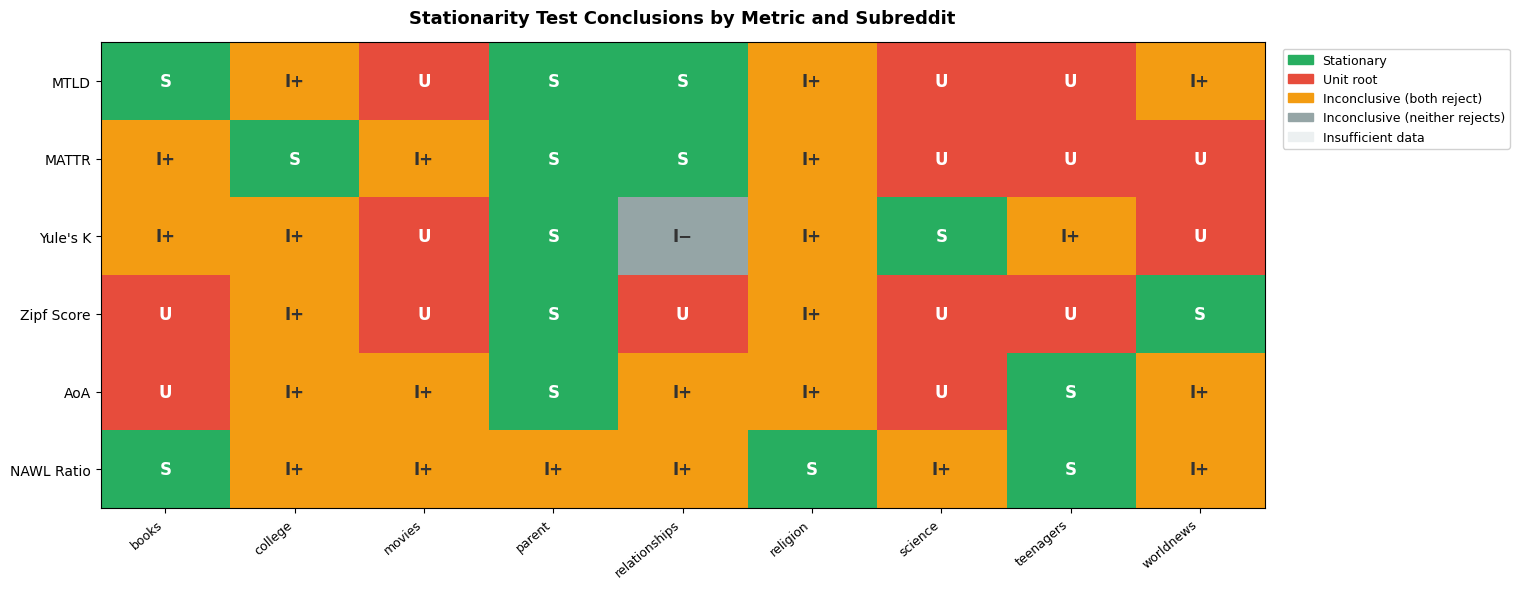

In [6]:
stationarity_results = run_stationarity_tests(agg)
summarize_stationarity(stationarity_results)
plot_stationarity_heatmap(stationarity_results)

### Autocorrelation Tests
Determine if the series is autocorrelated

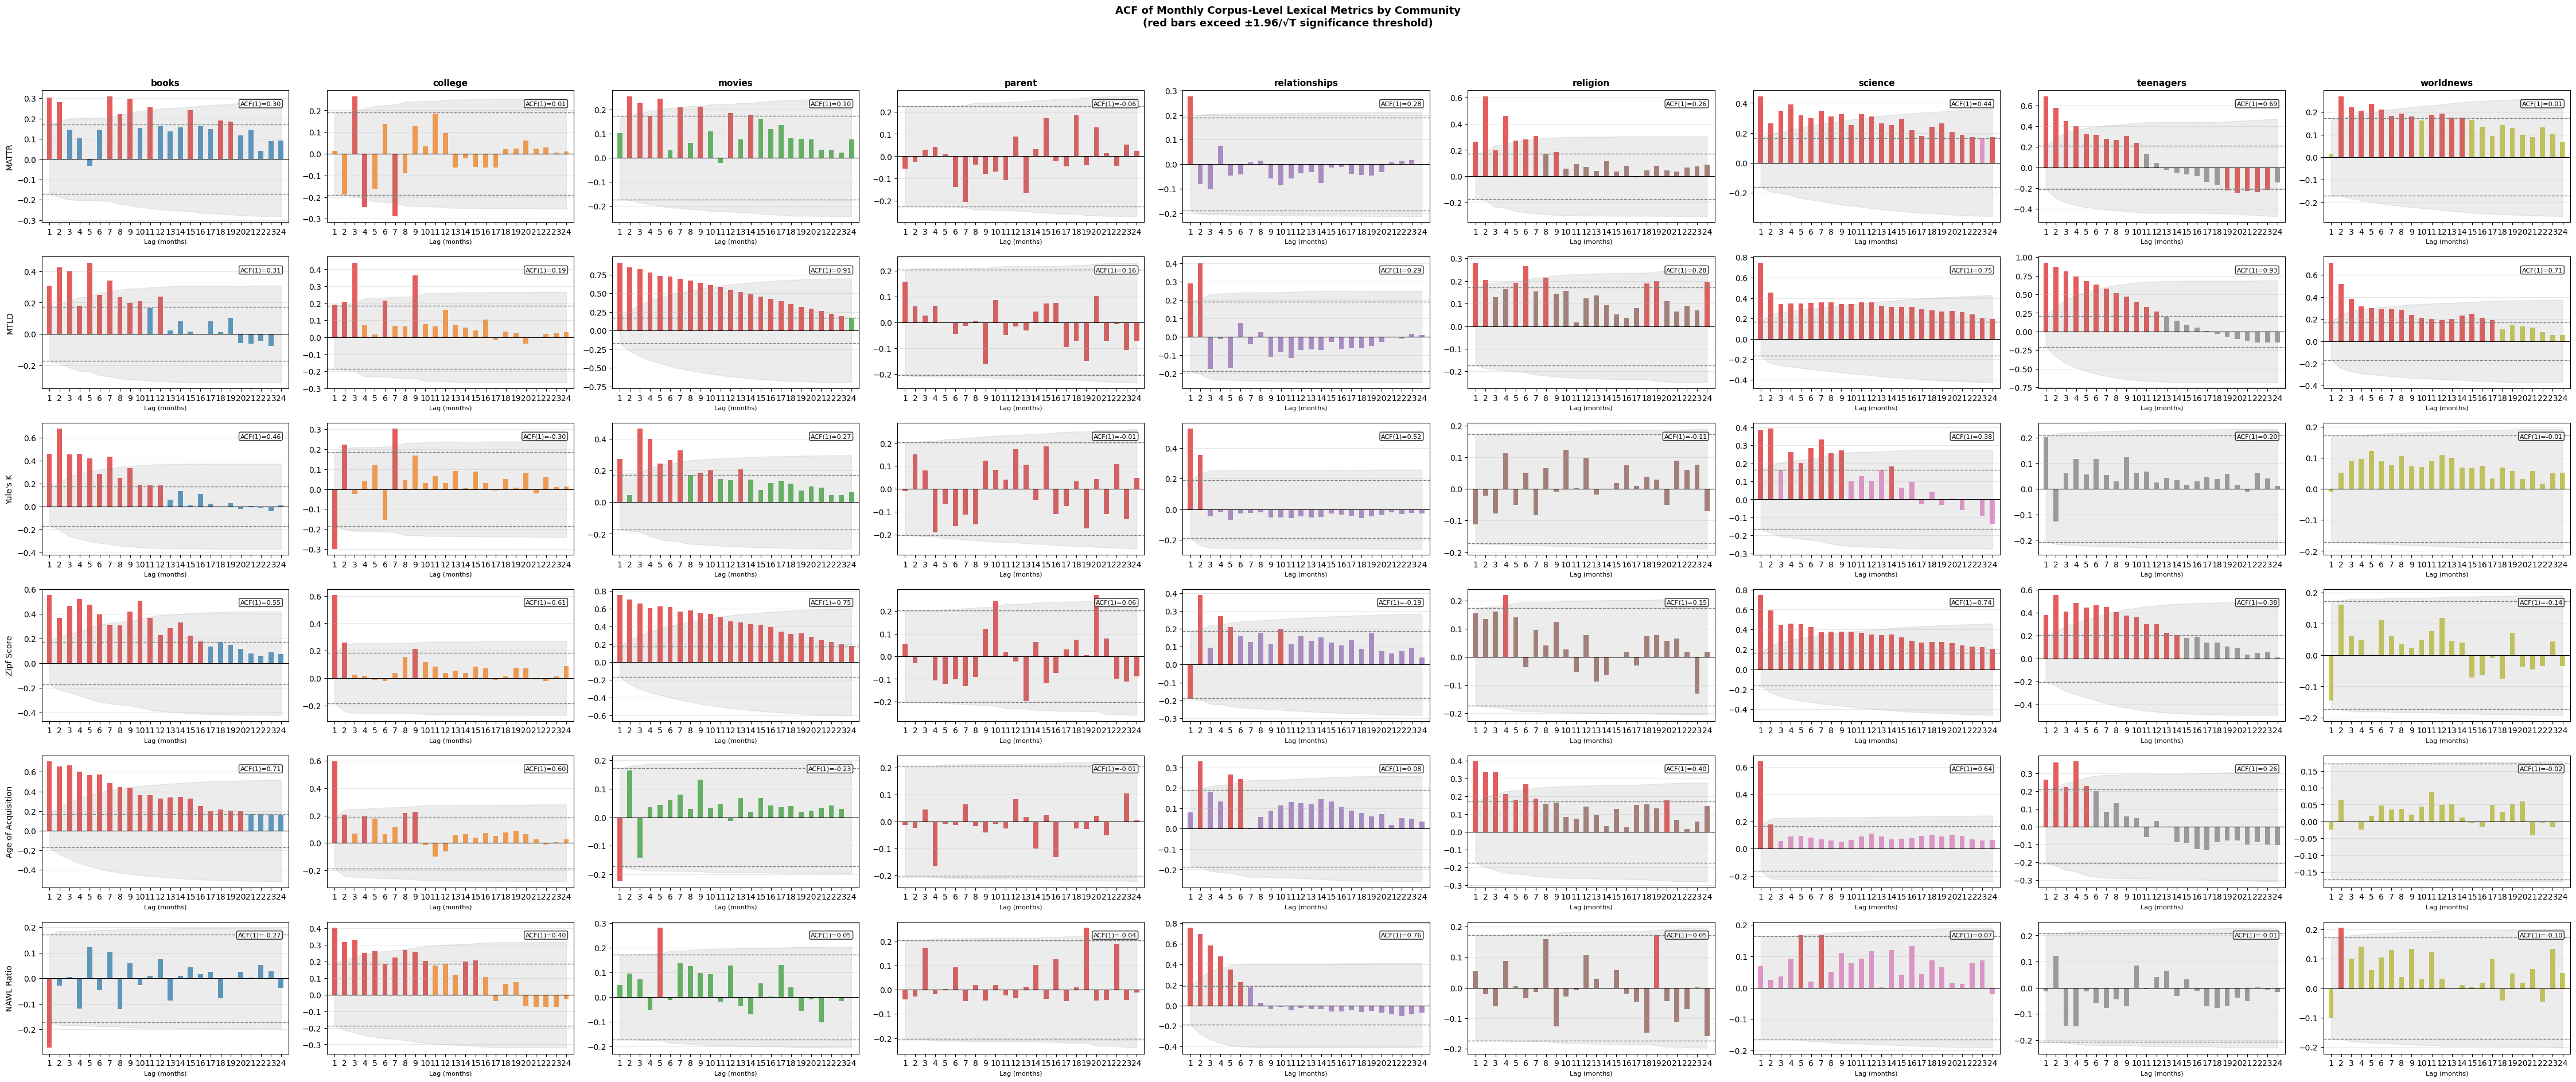

In [7]:
plot_acf_grid(agg, n_lags=24)

=== Ljung-Box Autocorrelation Test Summary ===
Lags tested: h=12, h=6   |   Conclusion based on: h=6
Total (subreddit × metric) series tested: 54

Overall conclusions:
  no autocorrelation          18  (33.3%)
  autocorrelated              36  (66.7%)
  insufficient data            0  (0.0%)

Breakdown by metric:
  MTLD               → most common: autocorrelated
  MATTR              → most common: autocorrelated
  Yule's K           → most common: autocorrelated
  Zipf Score         → most common: autocorrelated
  AoA                → most common: autocorrelated
  NAWL Ratio         → most common: no autocorrelation


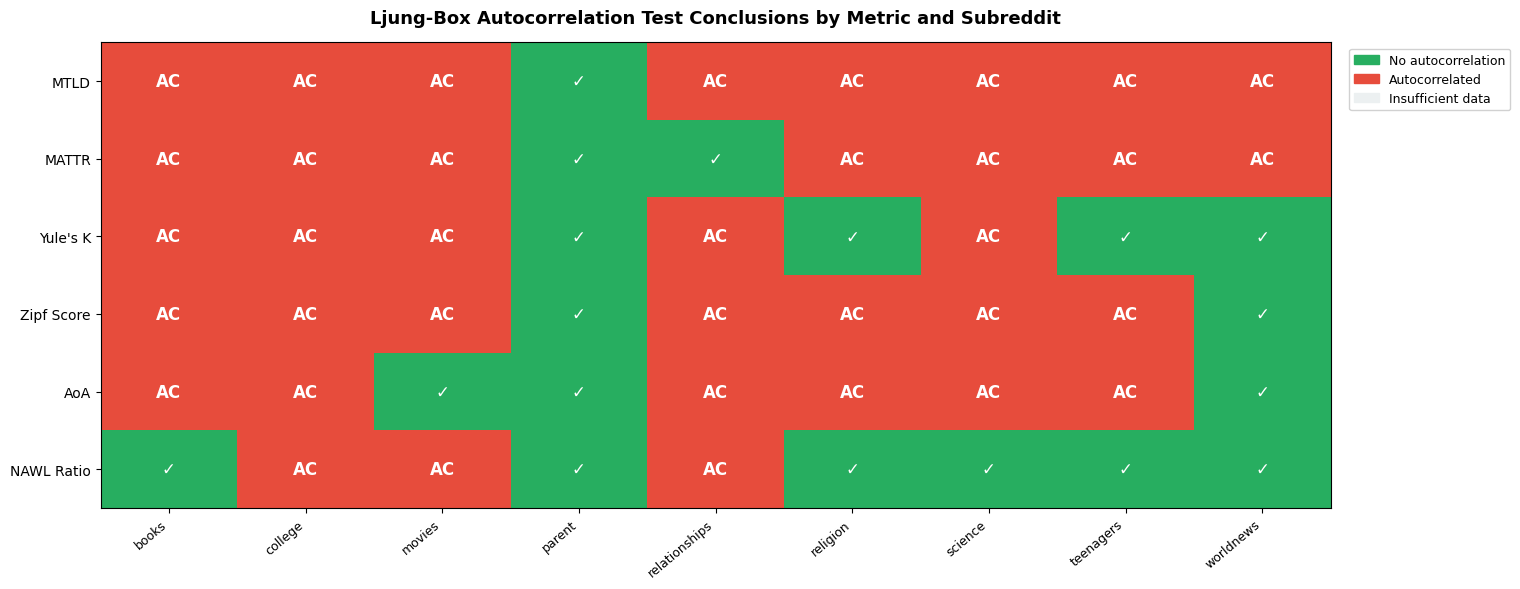

In [8]:
lb_results = run_ljung_box_tests(agg)
summarize_ljung_box(lb_results)
plot_ljung_box_heatmap(lb_results)

### First-Differencing

=== Stationarity Test Summary ===
Total (subreddit × metric) series tested: 54

Overall conclusions:
  stationary                               48  (88.9%)
  unit root                                 0  (0.0%)
  inconclusive (both reject)                6  (11.1%)
  inconclusive (neither rejects)            0  (0.0%)
  insufficient data                         0  (0.0%)

Breakdown by metric:
  MTLD               → most common: stationary
  MATTR              → most common: stationary
  Yule's K           → most common: stationary
  Zipf Score         → most common: stationary
  AoA                → most common: stationary
  NAWL Ratio         → most common: stationary


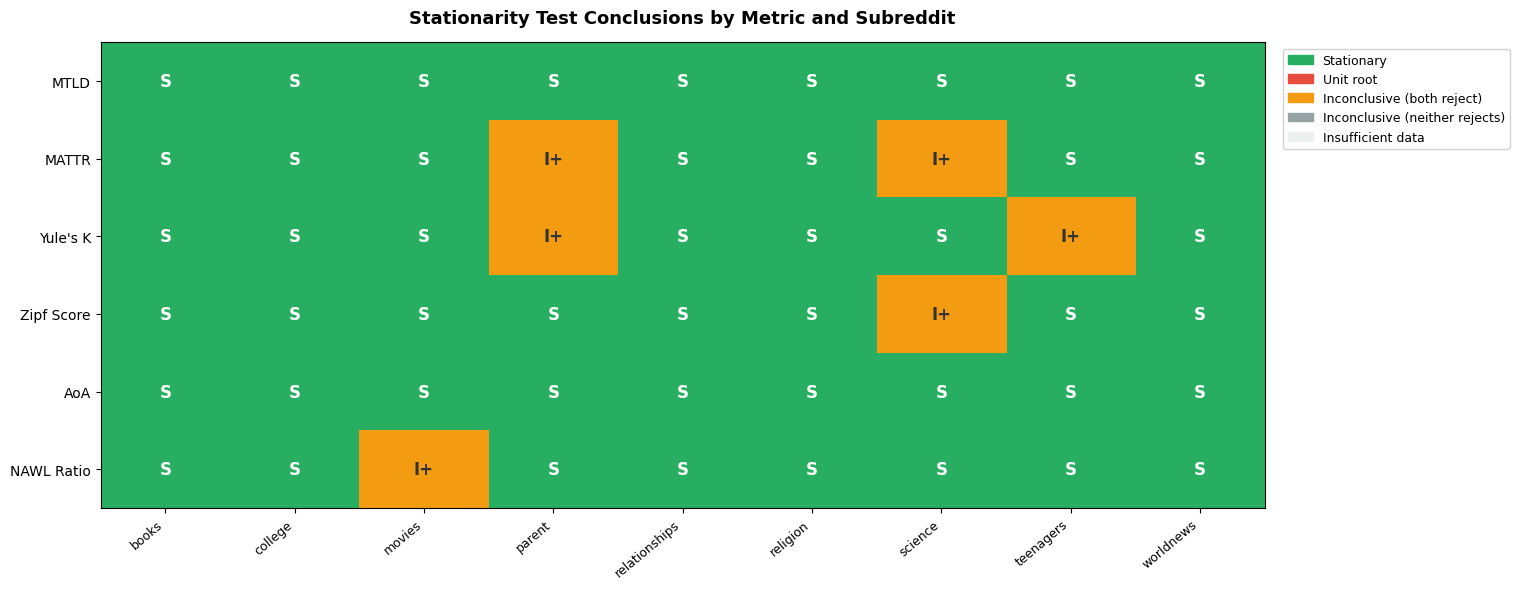

In [10]:
agg_diff = first_difference(agg)
stationarity_results_diff = run_stationarity_tests(agg_diff)   # should now show stationary
summarize_stationarity(stationarity_results_diff)
plot_stationarity_heatmap(stationarity_results_diff)

## Trend Testing

# User Frequency Analysis
Examine how user post frequency impacts lexical quality

## Posting Frequency Distribution Analysis
Examine the skew of speaker post-count distribution to motivate bin selection strategy.

In [4]:
from userfreq_analysis import summarize_freq_distribution, plot_freq_distribution, diagnose_quartile_bins

summarize_freq_distribution(df)

=== Speaker Post-Count Distribution ===
  N speakers      :    3,915,835
  Mean            :         9.93
  Median          :         2.00
  Std dev         :       120.05
  Skewness        :       114.35  (>1 = right-skewed)
  Excess kurtosis :     23358.19
  Min / Max       :      1 / 46,231

=== Percentiles ===
  P    1  :         1 posts
  P    5  :         1 posts
  P   10  :         1 posts
  P   25  :         1 posts
  P   50  :         2 posts
  P   75  :         4 posts
  P   90  :        12 posts
  P   95  :        26 posts
  P   99  :       122 posts
  P 99.9  :       809 posts

=== Low-Count Speaker Breakdown ===
  <=  1 post(s)  : 45.7% of speakers
  <=  2 post(s)  : 61.4% of speakers
  <=  3 post(s)  : 70.0% of speakers
  <=  5 post(s)  : 79.2% of speakers
  <= 10 post(s)  : 88.3% of speakers


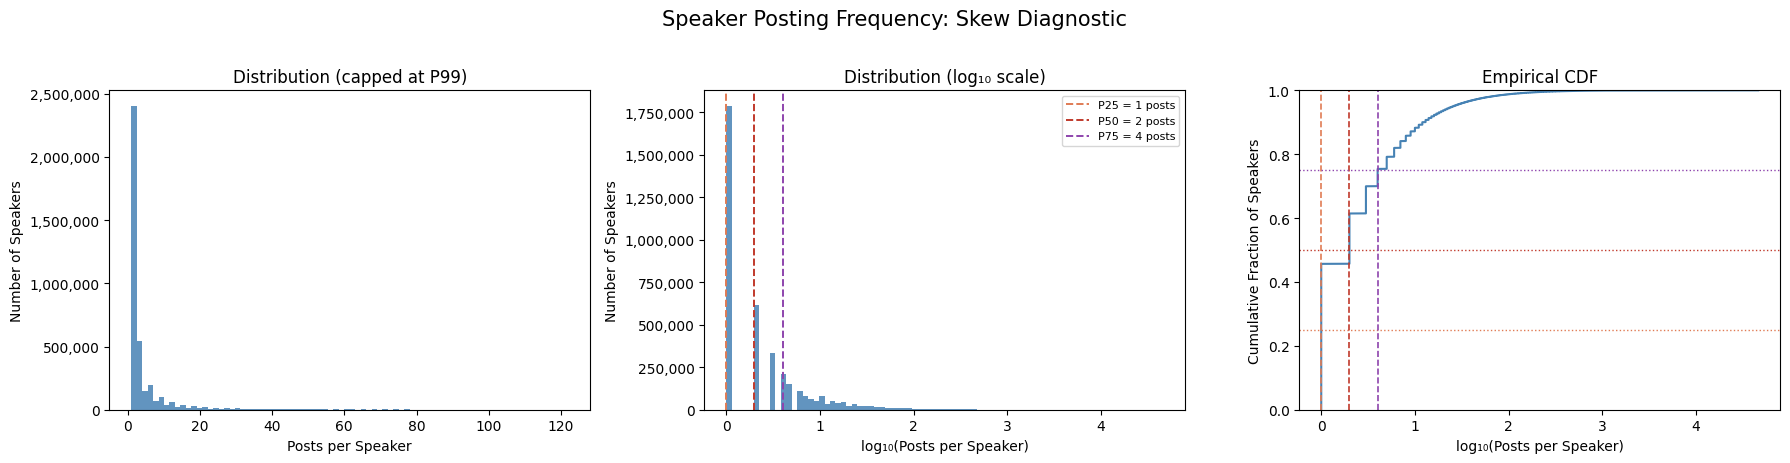

In [5]:
plot_freq_distribution(df)

## Data Prep

In [7]:
from userfreq_analysis import assign_freq_quartiles, prepare_panel

# For Analysis 2 (all speakers, no temporal filter)
df_q = assign_freq_quartiles(df)

# For Analysis 1 (speakers with >= min_obs monthly rows only)
panel = prepare_panel(df, min_obs=6)

Retained 765,172 / 3,915,836 speakers (19.5%) with >= 6 monthly observations.


## Analysis 1

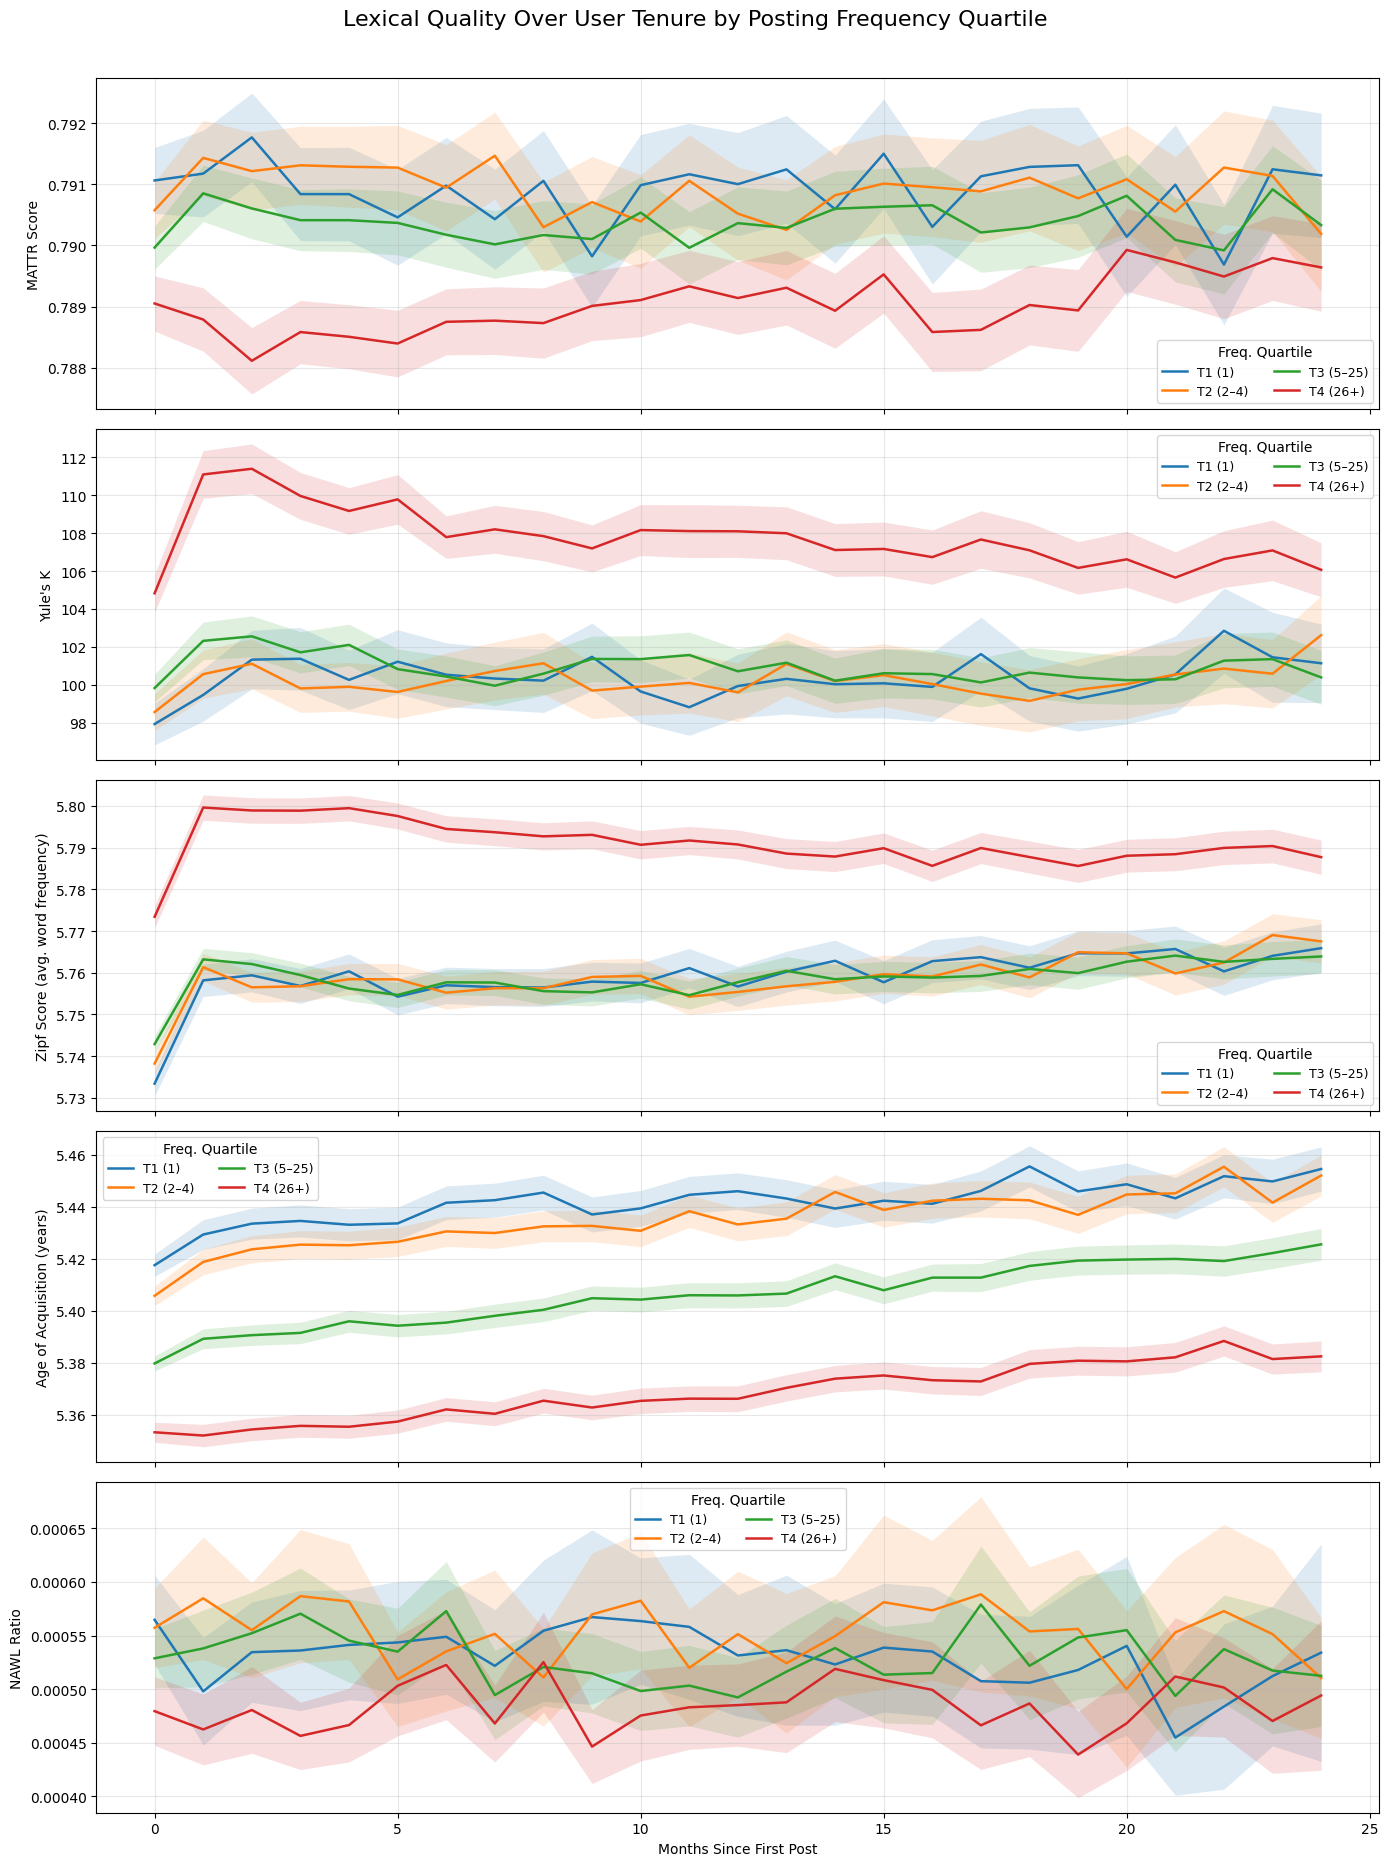

In [8]:
from userfreq_analysis import plot_quality_over_relative_time

plot_quality_over_relative_time(panel, max_relative_month=24)

## Analysis 2

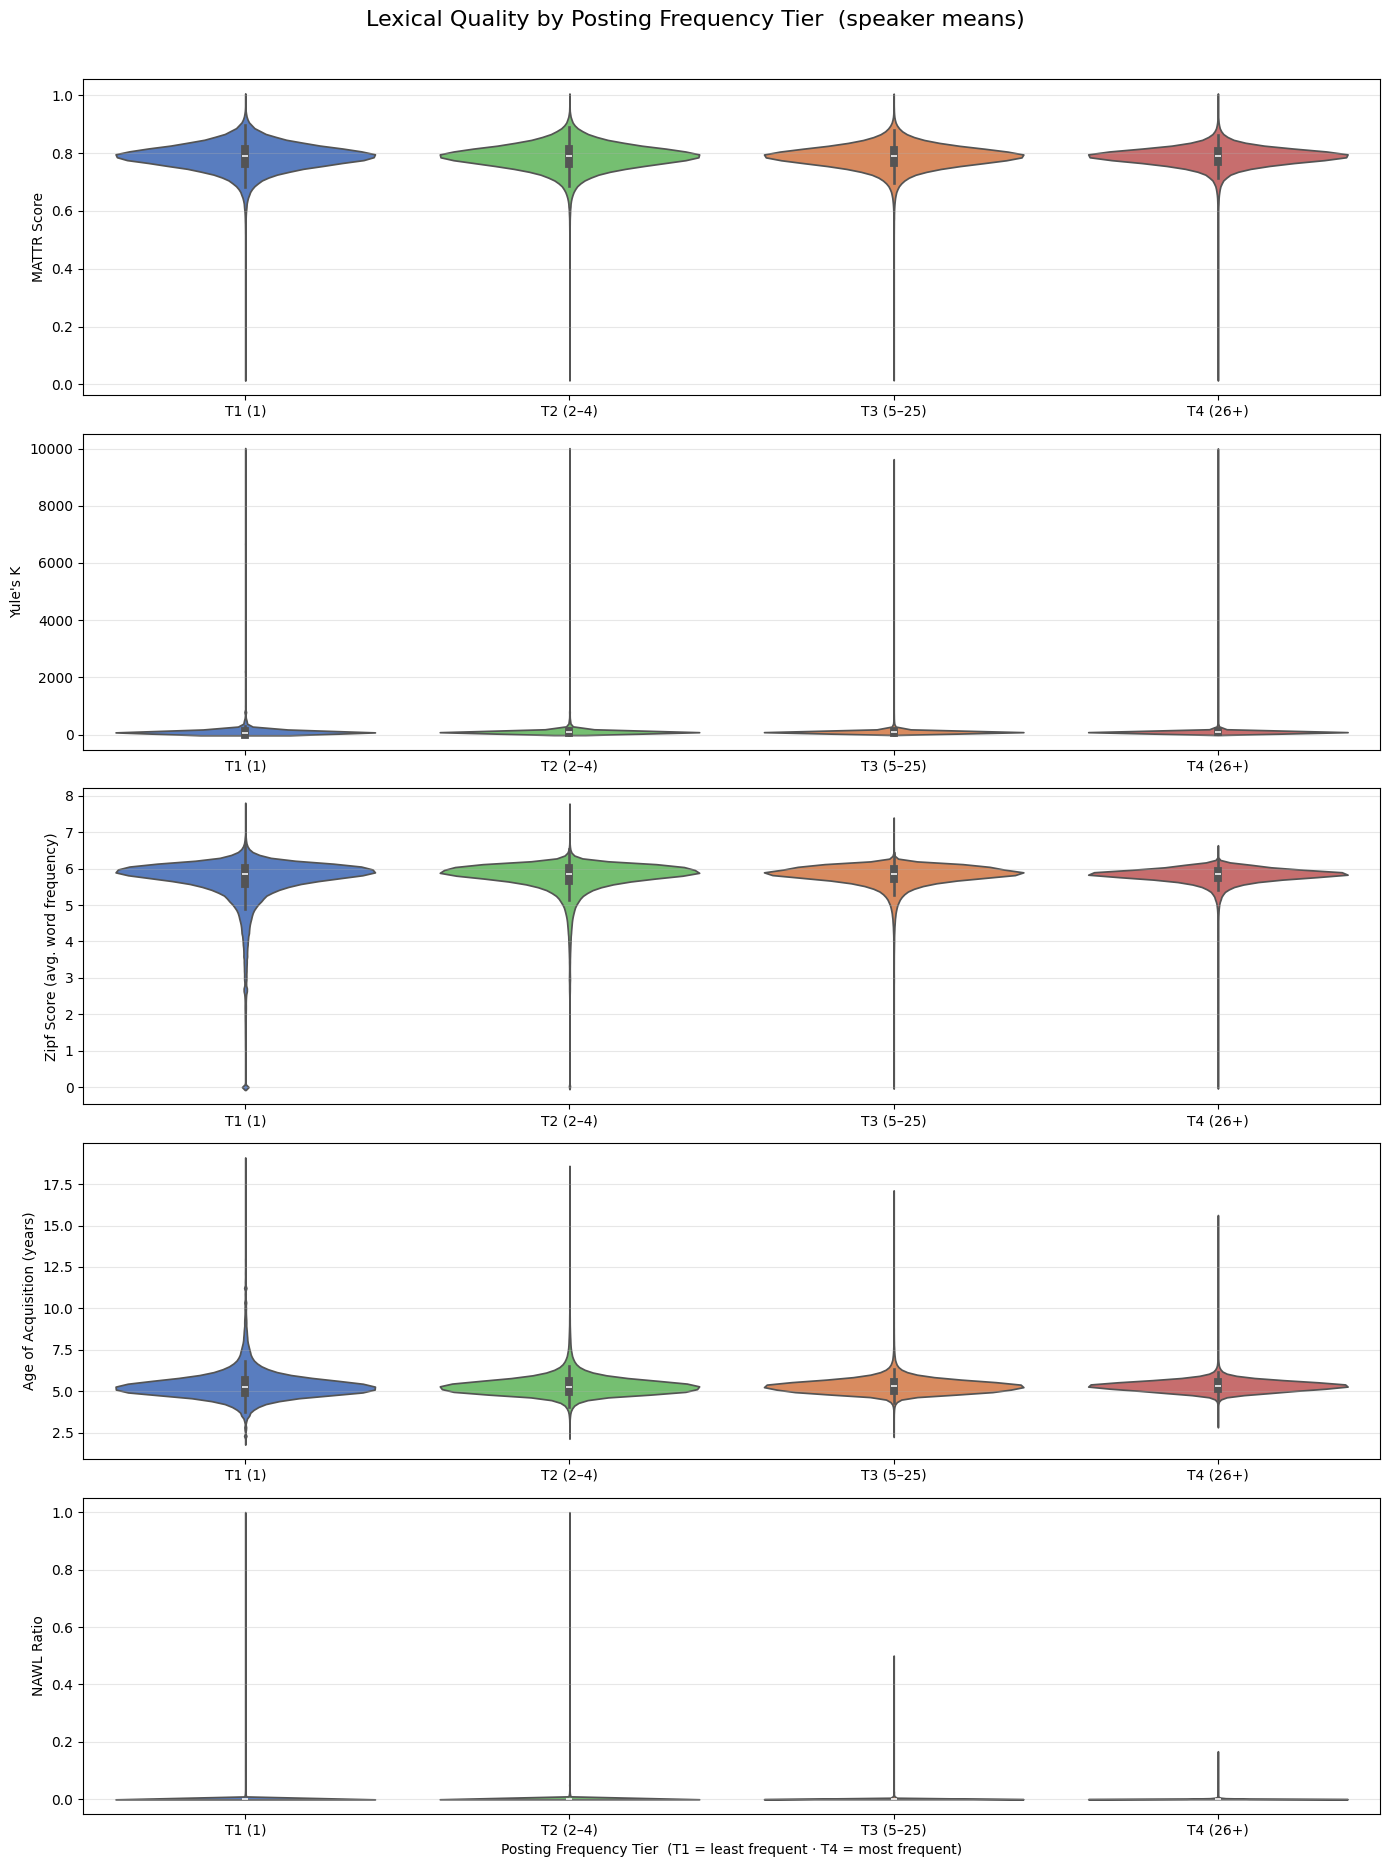

In [9]:
from userfreq_analysis import plot_quality_by_freq_quartile, run_freq_quartile_tests

plot_quality_by_freq_quartile(df_q, kind='violin')   # or kind='box'
results = run_freq_quartile_tests(df_q)

# Comparative Analysis
Examine how subreddits differ, if at all